# Global Solution 2026 — NeuroSpace Alert

## Computação Neuromórfica

### Sensor Neuromórfico de Baixo Consumo para Ambientes Espaciais

---

## Integrantes

Ricardo de Paiva Melo  
RM: 565522

Pedro Leal Murad  
RM: 565460

Jonas Alaf  
RM: 566479

---

## Cenário Escolhido

Rover lunar autônomo operando em ambiente extremo durante missões de exploração da superfície lunar.

## Condição Crítica Monitorada

Acúmulo simultâneo de:

- Temperatura elevada
- Radiação ionizante
- Poeira lunar

## Objetivo

Desenvolver e avaliar um sensor neuromórfico conceitual capaz de acumular informação localmente por meio de memória memristiva virtual e emitir alertas apenas quando uma condição crítica for detectada.

Essa abordagem reduz o envio contínuo de dados brutos, economiza energia e melhora a eficiência operacional de missões espaciais.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

## 1. Upload e leitura do dataset

O dataset fornecido simula 5 horas de operação de um sensor espacial, com uma leitura a cada 5 minutos.

As principais variáveis utilizadas são:

- temperatura;
- radiação;
- poeira;
- consumo;
- bateria;
- condição real simulada.

In [3]:
uploaded = files.upload()

Saving dataset_neurosensor_espacial_5h.csv to dataset_neurosensor_espacial_5h.csv


In [4]:
df = pd.read_csv("dataset_neurosensor_espacial_5h.csv")

df.head()

,tempo_min,temperatura_C,radiacao_uSv_h,poeira_pct,consumo_W,bateria_pct,indice_risco_real,condicao_real
0,0,22.6,0.27,11.5,18.5,99.1,0.060,NORMAL
1,5,22.2,0.23,6.0,18.0,99.1,0.040,NORMAL
2,10,22.8,0.23,10.1,18.7,98.4,0.056,NORMAL
3,15,23.5,0.32,13.5,18.6,97.6,0.083,NORMAL
4,20,22.3,0.35,7.3,18.2,98.7,0.060,NORMAL


In [5]:
print("Quantidade de registros:", len(df))
print("Colunas do dataset:")
print(df.columns.tolist())

df.info()

Quantidade de registros: 61
Colunas do dataset:
['tempo_min', 'temperatura_C', 'radiacao_uSv_h', 'poeira_pct', 'consumo_W', 'bateria_pct', 'indice_risco_real', 'condicao_real']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tempo_min          61 non-null     int64  
 1   temperatura_C      61 non-null     float64
 2   radiacao_uSv_h     61 non-null     float64
 3   poeira_pct         61 non-null     float64
 4   consumo_W          61 non-null     float64
 5   bateria_pct        61 non-null     float64
 6   indice_risco_real  61 non-null     float64
 7   condicao_real      61 non-null     object 
dtypes: float64(6), int64(1), object(1)
memory usage: 3.9+ KB


## 2. Análise inicial dos dados

Nesta etapa, analisamos o comportamento das variáveis ambientais ao longo da missão.

O objetivo é observar como temperatura, radiação e poeira evoluem antes da simulação do sensor neuromórfico.

In [6]:
df.describe()

,tempo_min,temperatura_C,radiacao_uSv_h,poeira_pct,consumo_W,bateria_pct,indice_risco_real
count,61.00000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000
mean,150.00000,34.995082,1.326885,40.911475,23.690164,79.172131,0.442000
std,88.76467,10.481928,0.859982,26.521985,4.528933,12.805274,0.320747
min,0.00000,22.200000,0.230000,6.000000,17.100000,58.100000,0.040000
25%,75.00000,23.900000,0.440000,13.500000,19.000000,67.400000,0.106000
50%,150.00000,33.600000,1.280000,36.700000,23.700000,78.900000,0.408000
75%,225.00000,45.700000,2.280000,69.100000,28.000000,91.100000,0.792000
max,300.00000,50.100000,2.530000,81.500000,31.000000,99.100000,0.887000


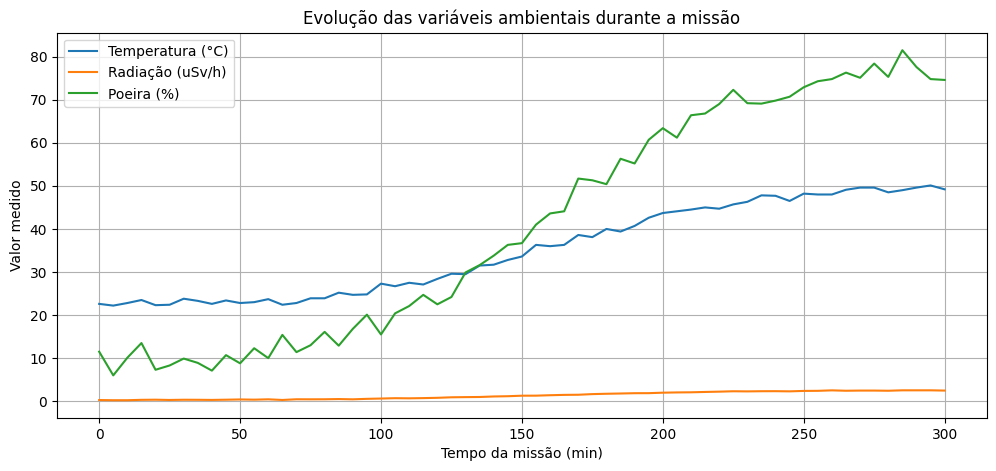

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(df["tempo_min"], df["temperatura_C"], label="Temperatura (°C)")
plt.plot(df["tempo_min"], df["radiacao_uSv_h"], label="Radiação (uSv/h)")
plt.plot(df["tempo_min"], df["poeira_pct"], label="Poeira (%)")

plt.title("Evolução das variáveis ambientais durante a missão")
plt.xlabel("Tempo da missão (min)")
plt.ylabel("Valor medido")
plt.legend()
plt.grid(True)
plt.show()

## 3. Criação do sinal conceitual V_entrada

O sensor neuromórfico combina temperatura, radiação e poeira em um único sinal chamado V_entrada.

Esse sinal representa uma entrada conceitual para o memristor virtual. Ele não é uma tensão física real, mas uma forma de transformar múltiplos fatores ambientais em um único índice elétrico de risco.

In [8]:
df["temp_norm"] = (df["temperatura_C"] - df["temperatura_C"].min()) / (df["temperatura_C"].max() - df["temperatura_C"].min())

df["rad_norm"] = (df["radiacao_uSv_h"] - df["radiacao_uSv_h"].min()) / (df["radiacao_uSv_h"].max() - df["radiacao_uSv_h"].min())

df["poeira_norm"] = (df["poeira_pct"] - df["poeira_pct"].min()) / (df["poeira_pct"].max() - df["poeira_pct"].min())

df["V_entrada"] = (
    12
    + df["temp_norm"] * 10
    + df["rad_norm"] * 14
    + df["poeira_norm"] * 10
)

df[["tempo_min", "temperatura_C", "radiacao_uSv_h", "poeira_pct", "V_entrada"]].head()

,tempo_min,temperatura_C,radiacao_uSv_h,poeira_pct,V_entrada
0,0,22.6,0.27,11.5,13.115324
1,5,22.2,0.23,6.0,12.000000
2,10,22.8,0.23,10.1,12.758100
3,15,23.5,0.32,13.5,14.007153
4,20,22.3,0.35,7.3,12.938463


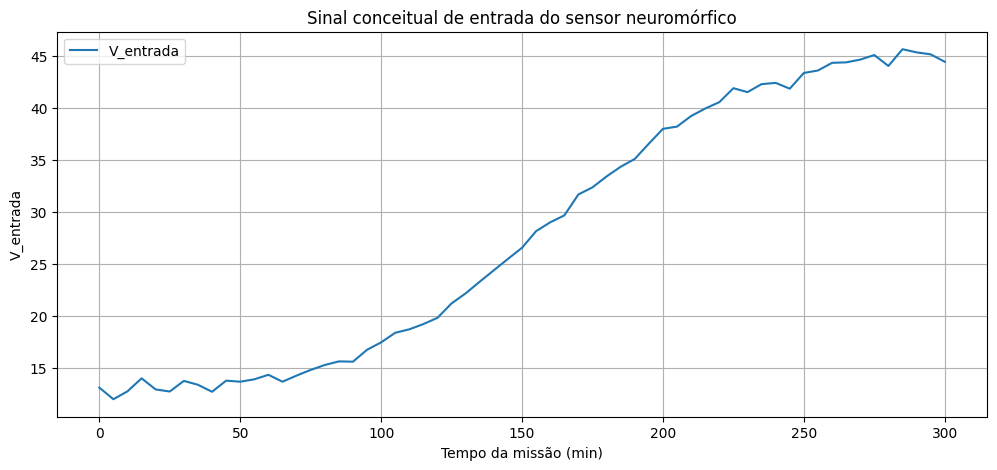

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(df["tempo_min"], df["V_entrada"], label="V_entrada")

plt.title("Sinal conceitual de entrada do sensor neuromórfico")
plt.xlabel("Tempo da missão (min)")
plt.ylabel("V_entrada")
plt.legend()
plt.grid(True)
plt.show()

## 4. Ajustes definidos pelo grupo

Foram definidos três perfis de sensor:

- Ajuste A: mais sensível;
- Ajuste B: equilibrado;
- Ajuste C: mais conservador.

Os valores foram escolhidos dentro das faixas sugeridas pelo enunciado, mas foram alterados para representar uma versão própria do grupo.

In [10]:
ajustes = {
    "Ajuste A - Sensível": {
        "V_limiar": 25,
        "taxa_chaveamento": 0.0065
    },
    "Ajuste B - Equilibrado": {
        "V_limiar": 29,
        "taxa_chaveamento": 0.0055
    },
    "Ajuste C - Conservador": {
        "V_limiar": 33,
        "taxa_chaveamento": 0.0040
    }
}

tabela_ajustes = pd.DataFrame(ajustes).T
tabela_ajustes

,V_limiar,taxa_chaveamento
Ajuste A - Sensível,25.0,0.0065
Ajuste B - Equilibrado,29.0,0.0055
Ajuste C - Conservador,33.0,0.0040


## 5. Simulação do memristor virtual

O memristor virtual funciona como uma memória local do risco acumulado.

Quando o sinal V_entrada ultrapassa o V_limiar, o estado do memristor começa a aumentar. Quanto maior o acúmulo, maior o nível de alerta.

A lógica usada foi:

- Estado menor que 0.35: LED APAGADO;
- Estado entre 0.35 e 0.70: LED AMARELO;
- Estado maior ou igual a 0.70: LED VERMELHO.

In [11]:
def simular_sensor(dados, nome_ajuste, V_limiar, taxa_chaveamento):
    dados_sim = dados.copy()

    estado_memristor = 0
    estados = []
    leds = []
    eventos = []

    for _, linha in dados_sim.iterrows():
        V = linha["V_entrada"]

        if V > V_limiar:
            excesso = V - V_limiar
            estado_memristor += excesso * taxa_chaveamento
        else:
            estado_memristor *= 0.995

        estado_memristor = min(max(estado_memristor, 0), 1)
        estados.append(estado_memristor)

        if estado_memristor < 0.35:
            led = "APAGADO"
            evento = "NORMAL"
        elif estado_memristor < 0.70:
            led = "AMARELO"
            evento = "OBSERVACAO"
        else:
            led = "VERMELHO"
            evento = "ALERTA_CRITICO"

        leds.append(led)
        eventos.append(evento)

    dados_sim["ajuste"] = nome_ajuste
    dados_sim["V_limiar"] = V_limiar
    dados_sim["taxa_chaveamento"] = taxa_chaveamento
    dados_sim["estado_memristor"] = estados
    dados_sim["LED"] = leds
    dados_sim["evento"] = eventos

    return dados_sim

In [12]:
simulacoes = []

for nome, params in ajustes.items():
    resultado = simular_sensor(
        df,
        nome,
        params["V_limiar"],
        params["taxa_chaveamento"]
    )
    simulacoes.append(resultado)

df_simulado = pd.concat(simulacoes, ignore_index=True)

df_simulado.head()

,tempo_min,temperatura_C,radiacao_uSv_h,poeira_pct,consumo_W,bateria_pct,indice_risco_real,condicao_real,temp_norm,rad_norm,poeira_norm,V_entrada,ajuste,V_limiar,taxa_chaveamento,estado_memristor,LED,evento
0,0,22.6,0.27,11.5,18.5,99.1,0.060,NORMAL,0.014337,0.017391,0.072848,13.115324,Ajuste A - Sensível,25,0.0065,0.0,APAGADO,NORMAL
1,5,22.2,0.23,6.0,18.0,99.1,0.040,NORMAL,0.000000,0.000000,0.000000,12.000000,Ajuste A - Sensível,25,0.0065,0.0,APAGADO,NORMAL
2,10,22.8,0.23,10.1,18.7,98.4,0.056,NORMAL,0.021505,0.000000,0.054305,12.758100,Ajuste A - Sensível,25,0.0065,0.0,APAGADO,NORMAL
3,15,23.5,0.32,13.5,18.6,97.6,0.083,NORMAL,0.046595,0.039130,0.099338,14.007153,Ajuste A - Sensível,25,0.0065,0.0,APAGADO,NORMAL
4,20,22.3,0.35,7.3,18.2,98.7,0.060,NORMAL,0.003584,0.052174,0.017219,12.938463,Ajuste A - Sensível,25,0.0065,0.0,APAGADO,NORMAL


## 6. Tabela de transições do LED

Nesta etapa, identificamos:

1. O tempo em que o LED deixou de ficar APAGADO;
2. O tempo em que o LED ficou VERMELHO.

Essa comparação permite avaliar qual ajuste detecta mais cedo e qual apresenta comportamento mais conservador.

In [13]:
resumo_transicoes = []

for nome in ajustes.keys():
    dados_ajuste = df_simulado[df_simulado["ajuste"] == nome]

    primeiro_alerta = dados_ajuste[dados_ajuste["LED"] != "APAGADO"]
    primeiro_vermelho = dados_ajuste[dados_ajuste["LED"] == "VERMELHO"]

    tempo_saiu_apagado = primeiro_alerta["tempo_min"].iloc[0] if len(primeiro_alerta) > 0 else None
    tempo_vermelho = primeiro_vermelho["tempo_min"].iloc[0] if len(primeiro_vermelho) > 0 else None

    resumo_transicoes.append({
        "Ajuste": nome,
        "V_limiar": ajustes[nome]["V_limiar"],
        "taxa_chaveamento": ajustes[nome]["taxa_chaveamento"],
        "LED deixou APAGADO em min": tempo_saiu_apagado,
        "LED ficou VERMELHO em min": tempo_vermelho
    })

resumo_transicoes = pd.DataFrame(resumo_transicoes)

resumo_transicoes

,Ajuste,V_limiar,taxa_chaveamento,LED deixou APAGADO em min,LED ficou VERMELHO em min
0,Ajuste A - Sensível,25,0.0065,190,215
1,Ajuste B - Equilibrado,29,0.0055,215,240
2,Ajuste C - Conservador,33,0.0040,250,290


## 7. Gráfico do estado do memristor

O gráfico abaixo mostra como o estado do memristor virtual evolui ao longo do tempo em cada ajuste.

Quanto mais rápido o estado cresce, mais sensível é o sensor.

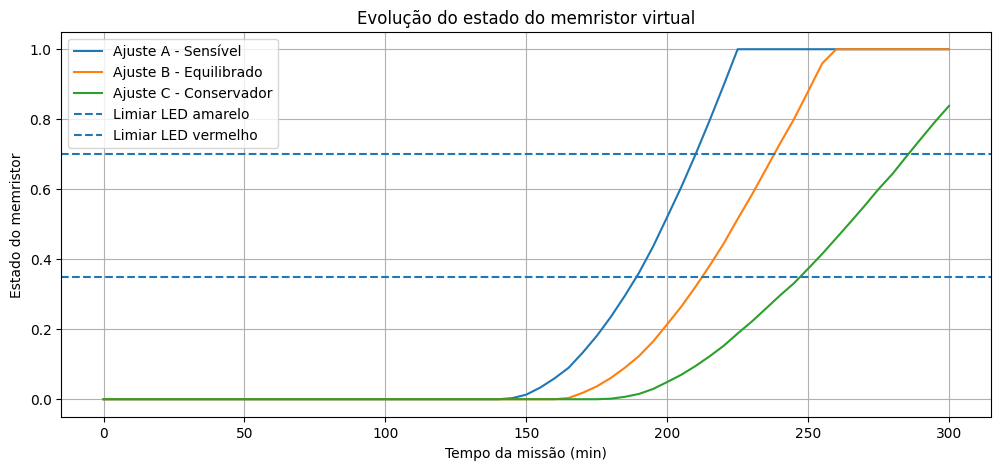

In [14]:
plt.figure(figsize=(12, 5))

for nome in ajustes.keys():
    dados_ajuste = df_simulado[df_simulado["ajuste"] == nome]

    plt.plot(
        dados_ajuste["tempo_min"],
        dados_ajuste["estado_memristor"],
        label=nome
    )

plt.axhline(0.35, linestyle="--", label="Limiar LED amarelo")
plt.axhline(0.70, linestyle="--", label="Limiar LED vermelho")

plt.title("Evolução do estado do memristor virtual")
plt.xlabel("Tempo da missão (min)")
plt.ylabel("Estado do memristor")
plt.legend()
plt.grid(True)
plt.show()

## 8. Gráfico das transições do LED

O gráfico abaixo mostra a mudança do LED ao longo da missão.

Essa visualização facilita a comparação entre o sensor sensível, o equilibrado e o conservador.

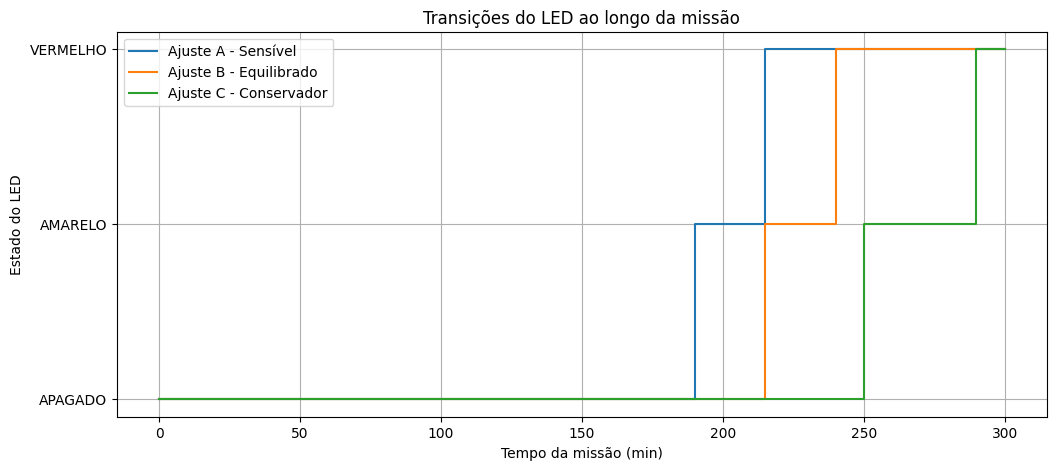

In [15]:
mapa_led = {
    "APAGADO": 0,
    "AMARELO": 1,
    "VERMELHO": 2
}

plt.figure(figsize=(12, 5))

for nome in ajustes.keys():
    dados_ajuste = df_simulado[df_simulado["ajuste"] == nome].copy()
    dados_ajuste["LED_num"] = dados_ajuste["LED"].map(mapa_led)

    plt.step(
        dados_ajuste["tempo_min"],
        dados_ajuste["LED_num"],
        where="post",
        label=nome
    )

plt.yticks([0, 1, 2], ["APAGADO", "AMARELO", "VERMELHO"])

plt.title("Transições do LED ao longo da missão")
plt.xlabel("Tempo da missão (min)")
plt.ylabel("Estado do LED")
plt.legend()
plt.grid(True)
plt.show()

## 9. Comparação técnica dos ajustes

O Ajuste A é o mais sensível. Ele tende a detectar alterações mais cedo, o que pode ser útil em situações de alto risco, mas também pode gerar alertas prematuros.

O Ajuste C é o mais conservador. Ele reduz a chance de falso alerta, mas pode atrasar a identificação de uma condição crítica.

O Ajuste B apresenta o melhor equilíbrio entre resposta rápida e estabilidade. Por isso, foi escolhido como ajuste recomendado para o protótipo conceitual.

## 10. Conexão com os Objetivos de Desenvolvimento Sustentável

Este projeto está alinhado ao ODS 9 — Indústria, Inovação e Infraestrutura.

A solução utiliza conceitos de computação neuromórfica, processamento local e computação de borda para criar um sistema autônomo capaz de operar em ambientes extremos com baixo consumo energético.

Além do uso espacial, a mesma lógica pode ser aplicada em estações ambientais remotas, monitoramento de desastres naturais e infraestruturas críticas conectadas por satélite.

In [16]:
ajuste_recomendado = "Ajuste B - Equilibrado"

saida_final = df_simulado[df_simulado["ajuste"] == ajuste_recomendado].copy()

saida_final[
    [
        "tempo_min",
        "temperatura_C",
        "radiacao_uSv_h",
        "poeira_pct",
        "consumo_W",
        "bateria_pct",
        "V_entrada",
        "V_limiar",
        "taxa_chaveamento",
        "estado_memristor",
        "LED",
        "evento"
    ]
].head(15)

,tempo_min,temperatura_C,radiacao_uSv_h,poeira_pct,consumo_W,bateria_pct,V_entrada,V_limiar,taxa_chaveamento,estado_memristor,LED,evento
61,0,22.6,0.27,11.5,18.5,99.1,13.115324,29,0.0055,0.0,APAGADO,NORMAL
62,5,22.2,0.23,6.0,18.0,99.1,12.000000,29,0.0055,0.0,APAGADO,NORMAL
63,10,22.8,0.23,10.1,18.7,98.4,12.758100,29,0.0055,0.0,APAGADO,NORMAL
64,15,23.5,0.32,13.5,18.6,97.6,14.007153,29,0.0055,0.0,APAGADO,NORMAL
65,20,22.3,0.35,7.3,18.2,98.7,12.938463,29,0.0055,0.0,APAGADO,NORMAL
66,25,22.4,0.29,8.3,17.6,97.2,12.741538,29,0.0055,0.0,APAGADO,NORMAL
67,30,23.8,0.34,9.9,17.1,95.4,13.759598,29,0.0055,0.0,APAGADO,NORMAL
68,35,23.3,0.33,8.9,18.0,96.3,13.387067,29,0.0055,0.0,APAGADO,NORMAL
69,40,22.6,0.30,7.1,19.1,96.5,12.715151,29,0.0055,0.0,APAGADO,NORMAL
70,45,23.4,0.35,10.7,18.6,95.1,13.783059,29,0.0055,0.0,APAGADO,NORMAL


In [17]:
nome_saida = "saida_sensor_espacial_Ajuste_B_equilibrado_grupo.csv"

saida_final.to_csv(nome_saida, index=False)

files.download(nome_saida)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Conclusão

A simulação demonstrou que um sensor neuromórfico conceitual pode atuar de forma eficiente em ambientes extremos, acumulando informação localmente e emitindo alertas apenas quando necessário.

O uso de memória memristiva virtual permite que o sistema considere o histórico recente das condições ambientais, em vez de reagir apenas a uma leitura isolada.

Essa característica reduz o envio contínuo de dados brutos, economiza energia e melhora a autonomia do sistema.

Após a comparação entre os três ajustes, o grupo recomenda o Ajuste B — Equilibrado, pois apresentou o melhor compromisso entre detecção antecipada, estabilidade e redução de alertas prematuros.